# M7: Assignment l Clustering with K-Means and DBSCAN


In this assignment I chose brest cancer dataset loaded it into jupyter notebook with pandas.

Kaggle dataset: https://www.kaggle.com/datasets/jealousleopard/goodreadsbooks 

In [5]:
# Importing necessary  libraires 
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt


In [6]:
# Creating DataFrame
# The goodreads.csv file had a couple of columns that were not correctly separated by a comma so used on_bad_lines to get rid of a couple of rows. 
good_reads_df = pd.read_csv("goodreads.csv", on_bad_lines = "skip")

In [7]:
# Taking a look at the counts it looks like on_bad_lines got rid of 5 rows.
good_reads_df.count()

bookID                11123
title                 11123
authors               11123
average_rating        11123
isbn                  11123
isbn13                11123
language_code         11123
  num_pages           11123
ratings_count         11123
text_reviews_count    11123
publication_date      11123
publisher             11123
dtype: int64

In [8]:
# Displaying first few rows.
good_reads_df.head()

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic


In [9]:
# Checking for null values 
good_reads_df.isna().sum()
# no null values

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

We can see that text_reviews and ratings_count features both have some rows with big differences in numbers. 

In [10]:
# The number of unique authors is 6639 this is not fully unique because there are some authors that appear multiple times because of them co-writing with others.
author_value_counts = good_reads_df.authors.unique().value_counts().sum()
author_value_counts

good_reads_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11123 entries, 0 to 11122
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   bookID              11123 non-null  int64  
 1   title               11123 non-null  str    
 2   authors             11123 non-null  str    
 3   average_rating      11123 non-null  float64
 4   isbn                11123 non-null  str    
 5   isbn13              11123 non-null  int64  
 6   language_code       11123 non-null  str    
 7     num_pages         11123 non-null  int64  
 8   ratings_count       11123 non-null  int64  
 9   text_reviews_count  11123 non-null  int64  
 10  publication_date    11123 non-null  str    
 11  publisher           11123 non-null  str    
dtypes: float64(1), int64(5), str(6)
memory usage: 1.0 MB


In [11]:
good_reads_df["num_pages"] = good_reads_df["  num_pages"]

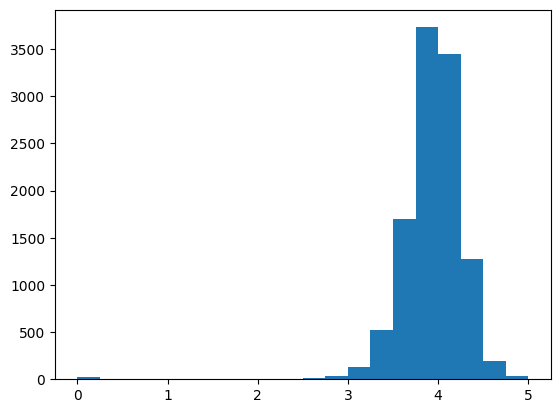

In [12]:
# Visualizing average ratings with histplot
plt.hist(good_reads_df['average_rating'], bins=20)
plt.show()

Looks like our dataset has many values that are within 4 to 4.5 stars.

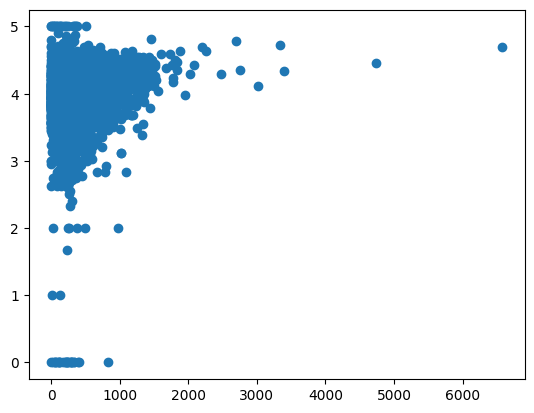

In [13]:
# Create scatter plot to see how  average rating aginst number of pages.
plt.scatter(x='num_pages', y='average_rating', data=good_reads_df)
plt.show()

It looks like most books in the dataset have  about less than 2,500 pages 

### K-means 

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import OneHotEncoder


In [15]:
good_reads_to_encode = good_reads_df[["title", "authors", "isbn","language_code","publication_date","publisher"]]

In [16]:
books_encoder = OneHotEncoder()
good_reads_1hot = pd.get_dummies(good_reads_df, drop_first=True)

In [17]:
good_reads_1hot

,bookID,average_rating,isbn13,num_pages,ratings_count,text_reviews_count,num_pages,title_$30 Film School: How to Write Direct Produce Shoot Edit Distribute Tour With and Sell Your Own No-Budget Digital Movie,title_'Salem's Lot,title_1 000 Places to See Before You Die,...,publisher_小学館,publisher_小学館 [Shōgakukan],publisher_時報出版,publisher_東立,publisher_皇冠文化出版有限公司,publisher_聯經出版事業股份有限公司,publisher_英文漢聲出版股份有限公司,publisher_角川書店 (Kadokawa Shoten),publisher_講談社,publisher_集英社
0,1,4.57,9780439785969,652,2095690,27591,652,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,4.49,9780439358071,870,2153167,29221,870,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,4,4.42,9780439554893,352,6333,244,352,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,5,4.56,9780439655484,435,2339585,36325,435,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,8,4.78,9780439682589,2690,41428,164,2690,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11118,45631,4.06,9781560254416,512,156,20,512,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11119,45633,4.08,9780140110876,635,783,56,635,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11120,45634,3.96,9780140131963,415,820,95,415,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11121,45639,3.72,9780060878825,434,769,139,434,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [18]:
# good_reads_num = good_reads_df[i for i in good_reads_df.columns]
numeric_df = []
for i in good_reads_df.columns:
    if good_reads_df[i].dtype == "int":
        numeric_df.append(i)
numeric_df = good_reads_df[numeric_df]

In [19]:
good_reads_1hot = pd.concat([numeric_df, good_reads_1hot], axis=1)
good_reads_1hot

,bookID,isbn13,num_pages,ratings_count,text_reviews_count,num_pages,bookID,average_rating,isbn13,num_pages,...,publisher_小学館,publisher_小学館 [Shōgakukan],publisher_時報出版,publisher_東立,publisher_皇冠文化出版有限公司,publisher_聯經出版事業股份有限公司,publisher_英文漢聲出版股份有限公司,publisher_角川書店 (Kadokawa Shoten),publisher_講談社,publisher_集英社
0,1,9780439785969,652,2095690,27591,652,1,4.57,9780439785969,652,...,False,False,False,False,False,False,False,False,False,False
1,2,9780439358071,870,2153167,29221,870,2,4.49,9780439358071,870,...,False,False,False,False,False,False,False,False,False,False
2,4,9780439554893,352,6333,244,352,4,4.42,9780439554893,352,...,False,False,False,False,False,False,False,False,False,False
3,5,9780439655484,435,2339585,36325,435,5,4.56,9780439655484,435,...,False,False,False,False,False,False,False,False,False,False
4,8,9780439682589,2690,41428,164,2690,8,4.78,9780439682589,2690,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11118,45631,9781560254416,512,156,20,512,45631,4.06,9781560254416,512,...,False,False,False,False,False,False,False,False,False,False
11119,45633,9780140110876,635,783,56,635,45633,4.08,9780140110876,635,...,False,False,False,False,False,False,False,False,False,False
11120,45634,9780140131963,415,820,95,415,45634,3.96,9780140131963,415,...,False,False,False,False,False,False,False,False,False,False
11121,45639,9780060878825,434,769,139,434,45639,3.72,9780060878825,434,...,False,False,False,False,False,False,False,False,False,False


In [20]:
# Scaling
scaler = StandardScaler()
good_reads_df_scaled = scaler.fit_transform(good_reads_1hot)


In [21]:
from sklearn.cluster import KMeans

In [22]:
# kmeans
kmeans = KMeans(n_clusters=2, random_state=42)
y_pred = kmeans.fit_predict(good_reads_df_scaled)
y_pred

array([0, 0, 0, ..., 0, 0, 0], shape=(11123,), dtype=int32)

In [23]:
kmeans.cluster_centers_

array([[-5.73464189e-04, -5.10309288e-05,  3.58995708e-04, ...,
         1.44834217e-05,  2.50905349e-05,  3.54929541e-05],
       [ 5.30980050e-01,  4.72503875e-02, -3.32400110e-01, ...,
        -1.34104415e-02, -2.32317445e-02, -3.28635178e-02]],
      shape=(2, 34113))

In [24]:
from sklearn.decomposition import PCA

In [25]:
good_reads_df_scaled[:,1]

array([0.04641441, 0.04641344, 0.04641389, ..., 0.04573792, 0.045559  ,
       0.06460552], shape=(11123,))

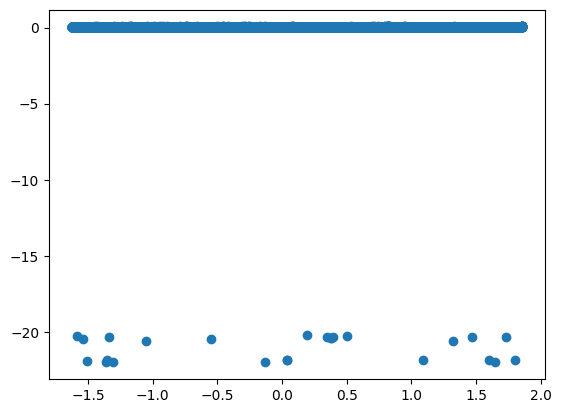

In [26]:
plt.scatter(good_reads_df_scaled[:,0],good_reads_df_scaled[:,1])
plt.show()

Theres a lot of values that are near zero when using one hot encoding so I used PCA 

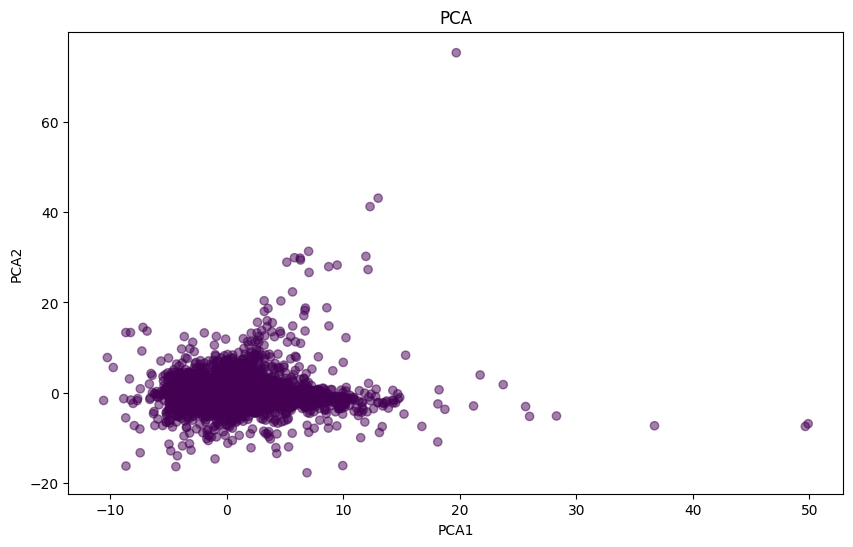

In [27]:
# Sowing graph for pca 
pca = PCA(n_components=2)

X_pca = pca.fit_transform(good_reads_df_scaled)

# 3. Plot the result (X_pca[:, 0] vs X_pca[:, 1])
plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap='viridis', alpha=0.5)
plt.title("PCA")
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

## DBSCAN


DBSCAN 
-	Apllying DBSCAN with scikit-learn DBSCAN to cluster data 
-	Expermented with different values of eps and min_samples

In [28]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(min_samples=4, eps=0.5)


In [29]:
clusters = dbscan.fit_predict(good_reads_df_scaled)
clusters


array([-1, -1, -1, ..., -1, -1, -1], shape=(11123,))

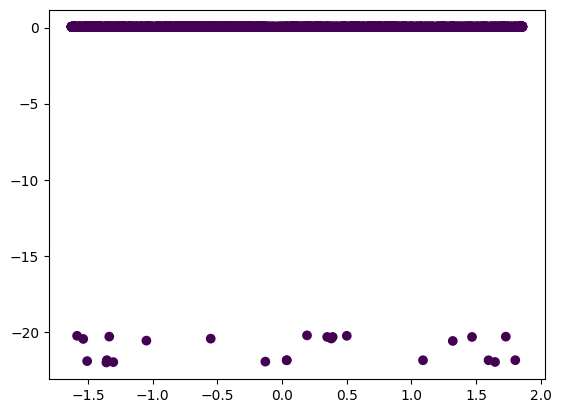

In [30]:
plt.scatter(good_reads_df_scaled[:, 0], good_reads_df_scaled[:, 1], c=clusters)
plt.show()

## summary